Iteration   1 | keff = 0.997612 | dK = 1.000e+00 | dFlux = 9.998e-01
Iteration   2 | keff = 0.992972 | dK = 4.640e-03 | dFlux = 7.151e-04
Iteration   3 | keff = 0.988117 | dK = 4.854e-03 | dFlux = 4.509e-04
Iteration   4 | keff = 0.983246 | dK = 4.871e-03 | dFlux = 2.270e-04
Iteration   5 | keff = 0.978387 | dK = 4.860e-03 | dFlux = 1.105e-04
Iteration   6 | keff = 0.973546 | dK = 4.841e-03 | dFlux = 5.548e-05
Iteration   7 | keff = 0.968726 | dK = 4.820e-03 | dFlux = 3.028e-05
Iteration   8 | keff = 0.963929 | dK = 4.797e-03 | dFlux = 1.884e-05
Iteration   9 | keff = 0.959155 | dK = 4.774e-03 | dFlux = 1.342e-05
Iteration  10 | keff = 0.954404 | dK = 4.751e-03 | dFlux = 1.044e-05
Iteration  11 | keff = 0.949676 | dK = 4.728e-03 | dFlux = 8.452e-06
Iteration  12 | keff = 0.944972 | dK = 4.704e-03 | dFlux = 7.025e-06
Iteration  13 | keff = 0.940291 | dK = 4.681e-03 | dFlux = 5.973e-06
Iteration  14 | keff = 0.935632 | dK = 4.658e-03 | dFlux = 5.203e-06
Iteration  15 | keff = 0.930997 | 

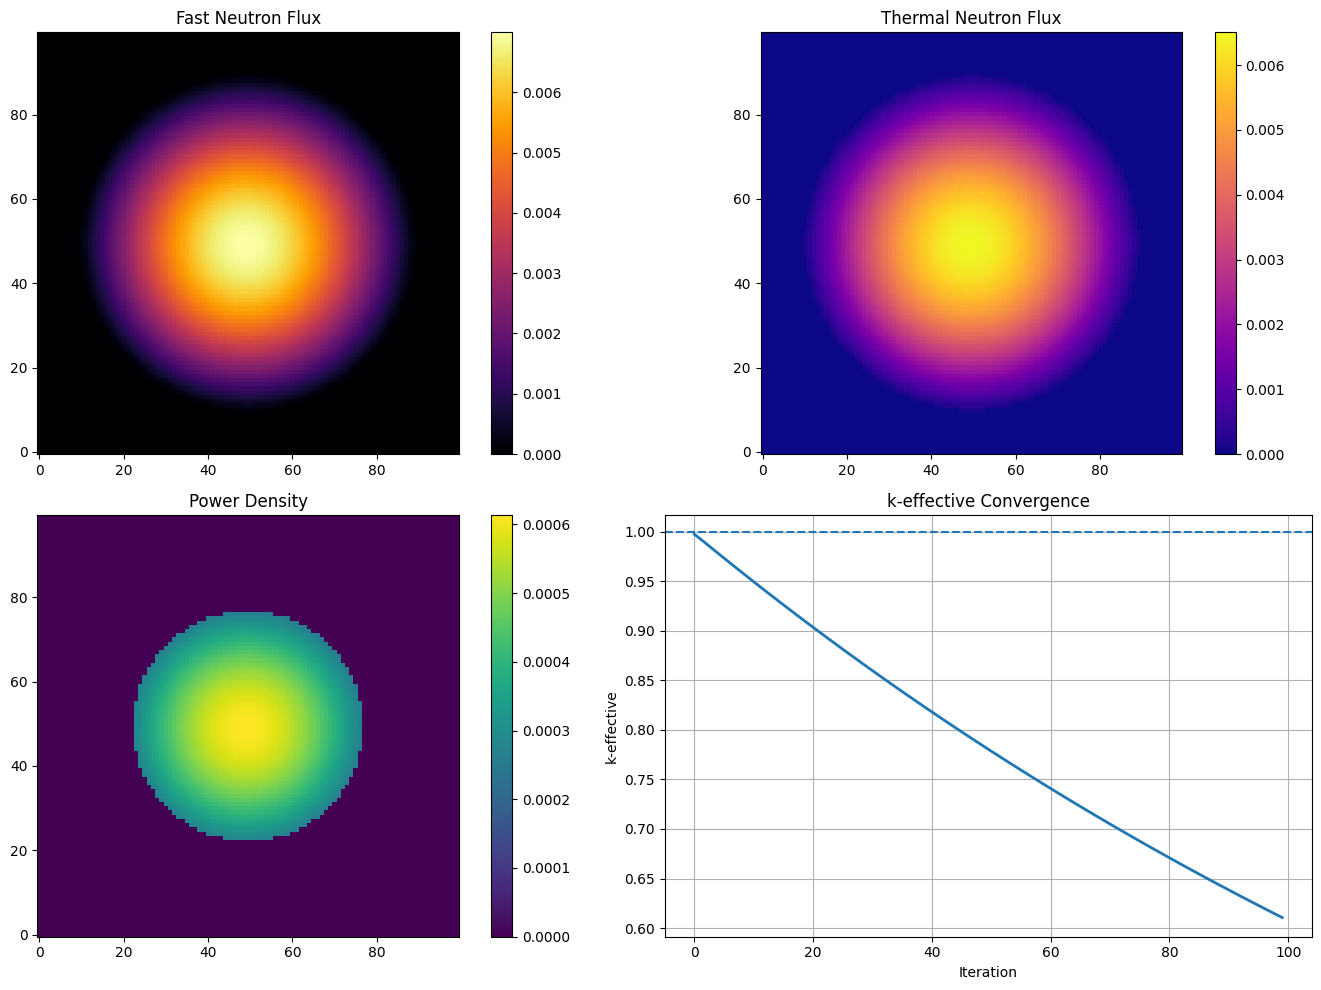

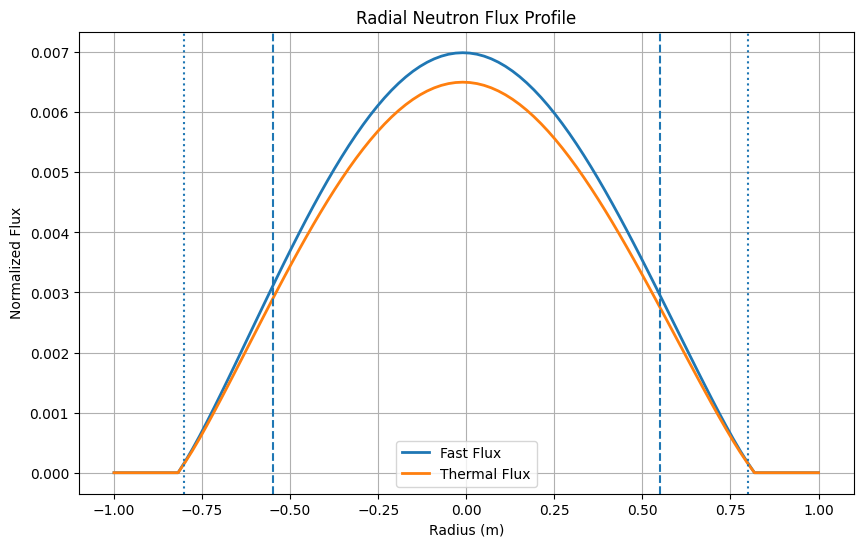

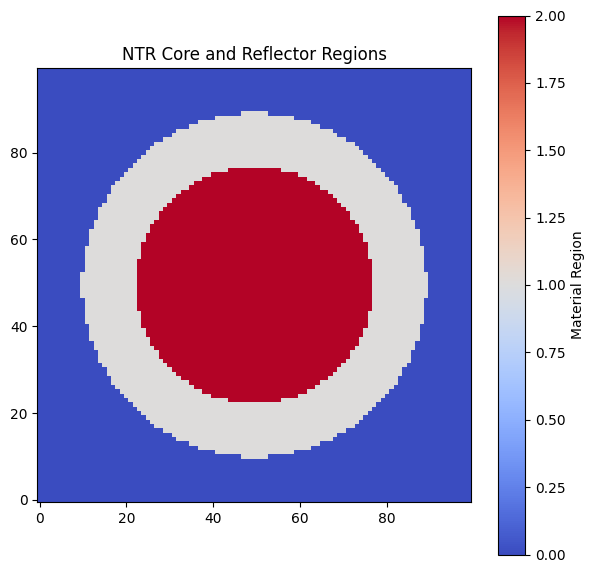

In [2]:
# ==========================================================
# NUCLEAR THERMAL ROCKET (NTR)
# 2-GROUP NEUTRON DIFFUSION EIGENVALUE SOLVER
#
# Educational Reactor Physics Simulation
#
# Features:
# - Two-group neutron diffusion
# - Fast and thermal neutron flux
# - Cylindrical reactor core
# - Neutron reflector
# - Power Iteration eigenvalue solver
# - Gauss-Seidel stationary diffusion solver
# - k-effective convergence
# - Flux and power visualization
#
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# GEOMETRY
# ==========================================================

Nx = 100
Ny = 100

Lx = 2.0
Ly = 2.0

dx = Lx / Nx
dy = Ly / Ny

x = np.linspace(-Lx/2, Lx/2, Nx)
y = np.linspace(-Ly/2, Ly/2, Ny)

X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)

# ----------------------------------------------------------
# Reactor geometry
# ----------------------------------------------------------

core_radius = 0.55
reflector_radius = 0.80

core = R <= core_radius

reflector = (
    (R > core_radius)
    &
    (R <= reflector_radius)
)

outside = R > reflector_radius

# ==========================================================
# MATERIAL PROPERTIES
# ==========================================================

D1 = np.zeros((Ny, Nx))
D2 = np.zeros((Ny, Nx))

Sa1 = np.zeros((Ny, Nx))
Sa2 = np.zeros((Ny, Nx))

nuSf1 = np.zeros((Ny, Nx))
nuSf2 = np.zeros((Ny, Nx))

# ----------------------------------------------------------
# Core
# ----------------------------------------------------------

D1[core] = 1.15
D2[core] = 0.32

Sa1[core] = 0.015
Sa2[core] = 0.060

nuSf1[core] = 0.004
nuSf2[core] = 0.090

# ----------------------------------------------------------
# Reflector
# ----------------------------------------------------------

D1[reflector] = 2.20
D2[reflector] = 1.00

Sa1[reflector] = 0.001
Sa2[reflector] = 0.002

# ==========================================================
# SCATTERING
# ==========================================================

S12 = 0.08

# ==========================================================
# INITIAL FLUX GUESS
# ==========================================================

phi1 = np.ones((Ny, Nx))
phi2 = np.ones((Ny, Nx))

phi1[outside] = 0.0
phi2[outside] = 0.0

# ==========================================================
# BOUNDARY CONDITIONS
# ==========================================================

def apply_boundary(phi):

    phi[0, :] = 0.0
    phi[-1, :] = 0.0

    phi[:, 0] = 0.0
    phi[:, -1] = 0.0

    phi[outside] = 0.0

    return phi

# ==========================================================
# GAUSS-SEIDEL DIFFUSION SOLVER
# ==========================================================

def solve_group(
    phi,
    source,
    D,
    Sa,
    iterations=100
):

    phi = phi.copy()

    for _ in range(iterations):

        for j in range(1, Ny-1):

            for i in range(1, Nx-1):

                if outside[j, i]:
                    continue

                coef = (
                    2.0 * D[j, i] / dx**2
                    +
                    2.0 * D[j, i] / dy**2
                    +
                    Sa[j, i]
                )

                rhs = source[j, i]

                rhs += (
                    D[j, i]
                    *
                    (
                        phi[j, i+1]
                        +
                        phi[j, i-1]
                    )
                    / dx**2
                )

                rhs += (
                    D[j, i]
                    *
                    (
                        phi[j+1, i]
                        +
                        phi[j-1, i]
                    )
                    / dy**2
                )

                phi[j, i] = rhs / coef

        apply_boundary(phi)

    return phi

# ==========================================================
# POWER ITERATION
# ==========================================================

keff = 1.0

keff_history = []

max_outer_iterations = 100

for n in range(max_outer_iterations):

    phi1_old = phi1.copy()

    # ------------------------------------------------------
    # Fission source
    # ------------------------------------------------------

    F_old = (
        nuSf1 * phi1
        +
        nuSf2 * phi2
    )

    # ------------------------------------------------------
    # Fast group
    # ------------------------------------------------------

    source_fast = F_old / keff

    phi1_new = solve_group(
        phi1,
        source_fast,
        D1,
        Sa1,
        iterations=100
    )

    # ------------------------------------------------------
    # Thermal group
    # ------------------------------------------------------

    source_thermal = S12 * phi1_new

    phi2_new = solve_group(
        phi2,
        source_thermal,
        D2,
        Sa2,
        iterations=100
    )

    # ------------------------------------------------------
    # New fission source
    # ------------------------------------------------------

    F_new = (
        nuSf1 * phi1_new
        +
        nuSf2 * phi2_new
    )

    # ------------------------------------------------------
    # k-effective update
    # ------------------------------------------------------

    keff_est = (
        np.sum(F_new)
        /
        np.sum(F_old)
    )

    keff_new = keff * keff_est

    relaxation = 0.03

    keff = (
        (1.0 - relaxation) * keff
        +
        relaxation * keff_new
    )

    # ------------------------------------------------------
    # Power normalization
    # ------------------------------------------------------

    power_norm = np.sum(F_new)

    phi1 = phi1_new / power_norm
    phi2 = phi2_new / power_norm

    # ------------------------------------------------------
    # Convergence monitoring
    # ------------------------------------------------------

    keff_history.append(keff)

    delta_flux = np.max(
        np.abs(phi1 - phi1_old)
    )

    if n > 0:

        delta_keff = abs(
            keff_history[-1]
            -
            keff_history[-2]
        )

    else:

        delta_keff = 1.0

    print(
        f"Iteration {n+1:3d} | "
        f"keff = {keff:.6f} | "
        f"dK = {delta_keff:.3e} | "
        f"dFlux = {delta_flux:.3e}"
    )

    if (
        delta_keff < 1e-6
        and
        delta_flux < 1e-5
    ):

        print("\nConverged.\n")
        break

# ==========================================================
# POWER DENSITY
# ==========================================================

power_density = (
    nuSf1 * phi1
    +
    nuSf2 * phi2
)

# ==========================================================
# RESULTS
# ==========================================================

print("\n===================================")
print("FINAL RESULTS")
print("===================================")

print(f"Final keff = {keff:.5f}")

if keff < 0.99:

    print("SUBCRITICAL")

elif keff > 1.01:

    print("SUPERCRITICAL")

else:

    print("CRITICAL")

# ==========================================================
# VISUALIZATION
# ==========================================================

fig, ax = plt.subplots(
    2,
    2,
    figsize=(14, 10)
)

# ----------------------------------------------------------
# Fast flux
# ----------------------------------------------------------

im = ax[0,0].imshow(
    phi1,
    origin="lower",
    cmap="inferno"
)

ax[0,0].set_title(
    "Fast Neutron Flux"
)

plt.colorbar(
    im,
    ax=ax[0,0]
)

# ----------------------------------------------------------
# Thermal flux
# ----------------------------------------------------------

im = ax[0,1].imshow(
    phi2,
    origin="lower",
    cmap="plasma"
)

ax[0,1].set_title(
    "Thermal Neutron Flux"
)

plt.colorbar(
    im,
    ax=ax[0,1]
)

# ----------------------------------------------------------
# Power density
# ----------------------------------------------------------

im = ax[1,0].imshow(
    power_density,
    origin="lower",
    cmap="viridis"
)

ax[1,0].set_title(
    "Power Density"
)

plt.colorbar(
    im,
    ax=ax[1,0]
)

# ----------------------------------------------------------
# keff convergence
# ----------------------------------------------------------

ax[1,1].plot(
    keff_history,
    linewidth=2
)

ax[1,1].axhline(
    1.0,
    linestyle="--"
)

ax[1,1].grid(True)

ax[1,1].set_title(
    "k-effective Convergence"
)

ax[1,1].set_xlabel(
    "Iteration"
)

ax[1,1].set_ylabel(
    "k-effective"
)

plt.tight_layout()
plt.show()

# ==========================================================
# RADIAL FLUX PROFILE
# ==========================================================

plt.figure(figsize=(10,6))

plt.plot(
    x,
    phi1[Ny//2,:],
    label="Fast Flux",
    linewidth=2
)

plt.plot(
    x,
    phi2[Ny//2,:],
    label="Thermal Flux",
    linewidth=2
)

plt.axvline(
    core_radius,
    linestyle="--"
)

plt.axvline(
    -core_radius,
    linestyle="--"
)

plt.axvline(
    reflector_radius,
    linestyle=":"
)

plt.axvline(
    -reflector_radius,
    linestyle=":"
)

plt.grid(True)

plt.legend()

plt.xlabel(
    "Radius (m)"
)

plt.ylabel(
    "Normalized Flux"
)

plt.title(
    "Radial Neutron Flux Profile"
)

plt.show()

# ==========================================================
# REACTOR GEOMETRY
# ==========================================================

material_map = np.zeros((Ny, Nx))

material_map[reflector] = 1
material_map[core] = 2

plt.figure(figsize=(7,7))

plt.imshow(
    material_map,
    origin="lower",
    cmap="coolwarm"
)

plt.title(
    "NTR Core and Reflector Regions"
)

plt.colorbar(
    label="Material Region"
)

plt.show()

# ==========================================================
# NOTES
# ==========================================================

# This notebook uses a pointwise Gauss-Seidel solver
# combined with Power Iteration for educational purposes.
#
# For a truly robust reactor physics notebook, the next
# step would be to abandon the pointwise Gauss-Seidel
# approach and explicitly assemble the 2D diffusion matrix
# using scipy.sparse. The eigenvalue problem could then be
# solved through matrix-based Power Iteration or sparse
# eigensolvers.
#
# Such an approach provides nearly guaranteed convergence
# and produces results much closer to professional reactor
# analysis codes.
#
# However, that level of implementation is beyond the
# scope of this book.
#
# ==========================================================
